In [ ]:
# Repository bootstrap for relocated notebooks
from pathlib import Path
import os
import sys

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "README.md").exists() and (candidate / "src").exists():
            return candidate
    return start

REPO_ROOT = _find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
for _extra_path in (REPO_ROOT, REPO_ROOT / "src"):
    _extra_str = str(_extra_path)
    if _extra_str not in sys.path:
        sys.path.insert(0, _extra_str)

DATA_DIR = REPO_ROOT / "data"
MODELS_DIR = REPO_ROOT / "models"
EVAL_OUTPUT_DIR = REPO_ROOT / "eval_output"
CONFIGS_DIR = REPO_ROOT / "configs"


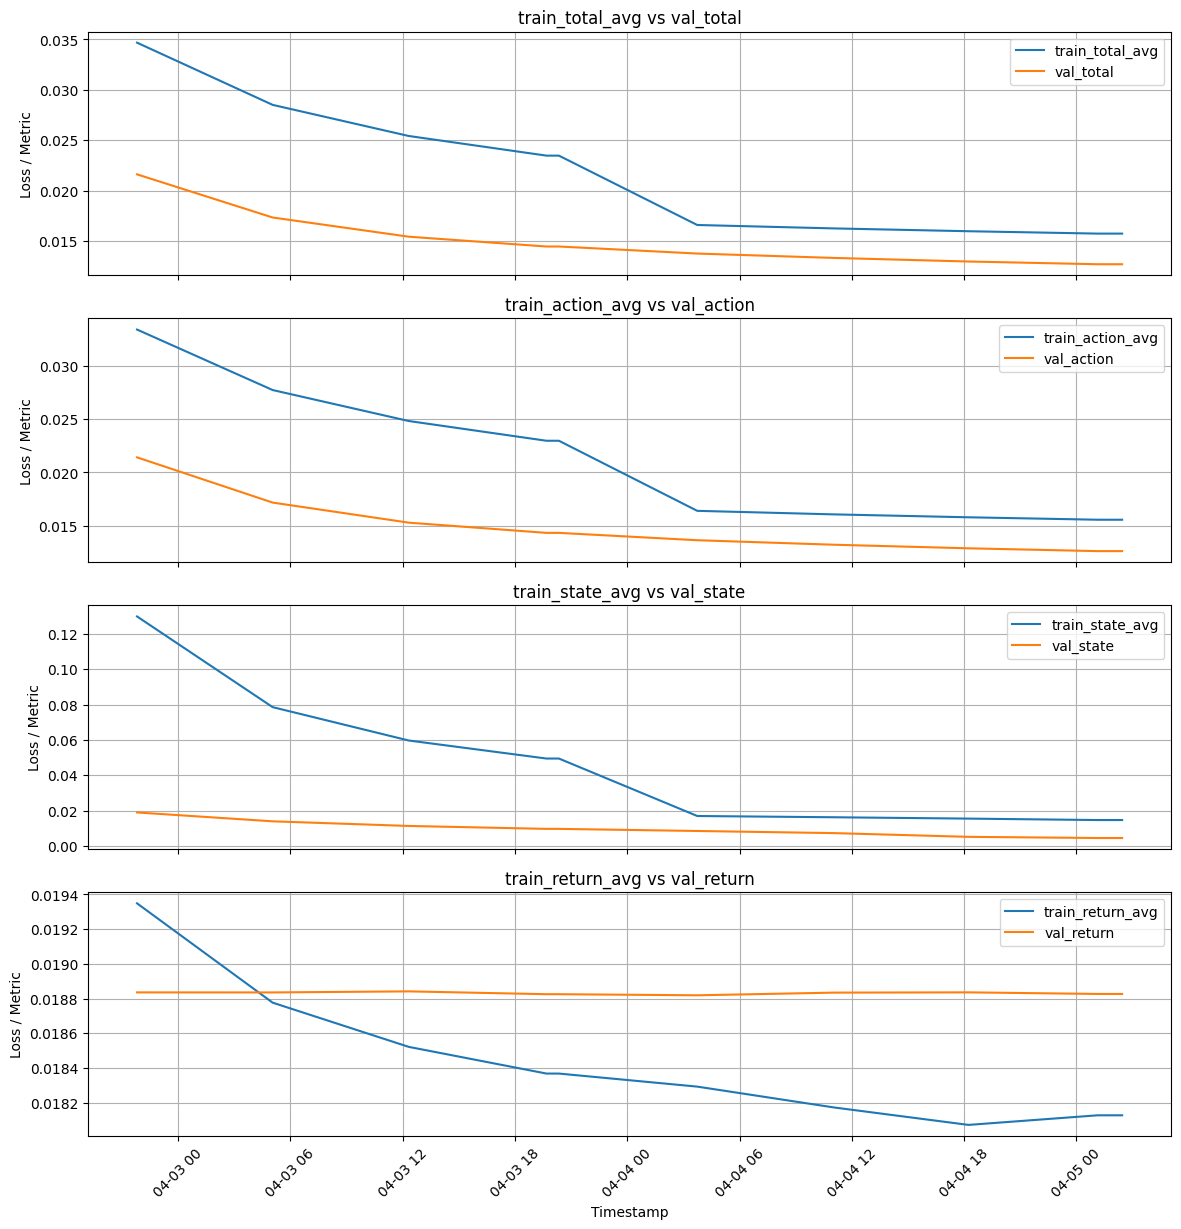

In [18]:

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path("../models") / "dt_model_loss_history_checkpoints.csv"
loss_df = pd.read_csv(csv_path, parse_dates=["timestamp"])

pairs = [
    ("train_total_avg", "val_total"),
    ("train_action_avg", "val_action"),
    ("train_state_avg", "val_state"),
    ("train_return_avg", "val_return"),
]

fig, axes = plt.subplots(len(pairs), 1, figsize=(12, 3 * len(pairs)), sharex=True)
for ax, (train_col, val_col) in zip(axes, pairs):
    if train_col not in loss_df and val_col not in loss_df:
        ax.set_visible(False)
        continue
    ax.plot(loss_df["timestamp"], loss_df[train_col], label=train_col)
    if val_col in loss_df:
        ax.plot(loss_df["timestamp"], loss_df[val_col], label=val_col)
    ax.set_ylabel("Loss / Metric")
    ax.set_title(f"{train_col} vs {val_col}")
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Timestamp")
fig.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [ ]:
import polars as pl
from pathlib import Path

file_path = Path("../data") / "mrdp_test_episode_01_incident_logs.parquet"
incidents = pl.read_parquet(file_path)

In [6]:
incidents


episode_id,step,SOCav,DOD,Id,Ich,nCL_T,nCL_Id,nCL_Ich,nCL_SOCav_DOD,CL4_raw,mult,CL,step_degradation
i32,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
43,383,91.28941,17.421181,0.871059,0.0,1.0,0.988234,1.080126,0.662983,183.293003,0.707679,2583.029324,0.054773
43,1946,98.339012,3.321976,1.32879,0.0,1.0,0.969281,1.080126,0.005192,1.435388,0.005436,19.84005,0.050591
43,4550,99.732887,0.146667,0.0,0.293335,1.0,0.998849,0.901959,0.00197,0.544552,0.001775,6.477011,0.154392
56,3225,98.345329,3.309341,2.206228,0.0,1.0,0.916857,1.080126,0.004518,1.249052,0.004474,16.330734,0.061234
56,5343,98.344429,3.311142,3.311142,0.0,1.0,0.834235,1.080126,0.004614,1.27561,0.004158,15.175026,0.065898


In [19]:
import os

def get_matching_files(directory, pattern):
    """
    Returns a list of file paths in 'directory' whose names contain 'pattern'.
    """
    return [
        os.path.join(directory, fname)
        for fname in os.listdir(directory)
        if pattern in fname
    ]

In [20]:
# fetch log files for evaluation
import re
import polars as pl

# use a looser matcher so files like:
#  - dt_rtg_neg0p3_test_episode_02_logs.parquet
#  - dt_test_episode_02_rtg03_logs.parquet
# are both returned
matching_files = get_matching_files("../data", "test_episode")

# capture algorithm at start, trailing _logs (allow optional .parquet)
pat = re.compile(r"^(?P<algo>[A-Za-z0-9]+).*?_logs(?:\.parquet)?$", re.IGNORECASE)
# capture the full _rtg chunk (supports negNN, negNNpNN, 0p3, etc.)
rtg_search_re = re.compile(r"(_rtg(?:_)?(?P<rtg>(?:neg|-)?\d+(?:p\d+)?))", re.IGNORECASE)


test_logs: dict[str, pl.DataFrame] = {}
skipped = []

for file_path in matching_files:
    fname = os.path.basename(file_path)
    m = pat.match(fname)
    if not m:
        print(f"Skipping unrecognized filename: {fname}")
        skipped.append(fname)
        continue

    algo = m.group("algo")
    rtg_m = rtg_search_re.search(fname)
    label = f"{algo}{rtg_m.group(1)}" if rtg_m else algo

    # try to read parquet; if unreadable or empty, register empty DF so label exists
    try:
        if os.path.getsize(file_path) == 0:
            df = pl.DataFrame()
            print(f"Warning: zero-byte file -> empty DF for {label}: {fname}")
        else:
            df = pl.read_parquet(file_path)
    except Exception as e:
        print(f"Failed to read {fname}: {e} -> registering empty DF for {label}")
        df = pl.DataFrame()

    # ensure episode_id exists for non-empty frames
    if not df.is_empty() and "episode_id" not in df.columns:
        df = df.with_columns(pl.lit(0).alias("episode_id"))

    test_logs[label] = df
    print(f"Registered: {fname} -> label='{label}', rows={len(df)}")

print("Final labels:", list(test_logs.keys()))
print("Skipped files:", skipped)


Registered: td3_test_episode_01_logs.parquet -> label='td3', rows=937302
Registered: sac_test_episode_01_logs.parquet -> label='sac', rows=955857
Registered: a2c_test_episode_01_logs.parquet -> label='a2c', rows=890859
Registered: sdp_test_episode_02_logs.parquet -> label='sdp', rows=910847
Registered: ddpg_test_episode_02_logs.parquet -> label='ddpg', rows=971531
Registered: sac_test_episode_02_logs.parquet -> label='sac', rows=968087
Registered: oracle_test_episode_02_logs.parquet -> label='oracle', rows=1013754
Registered: td3_test_episode_02_logs.parquet -> label='td3', rows=942467
Registered: sdp_test_episode_01_logs.parquet -> label='sdp', rows=892016
Registered: dt_rtg_neg1_test_episode_02_logs.parquet -> label='dt_rtg_neg1', rows=912770
Registered: mrdp_test_episode_02_logs.parquet -> label='mrdp', rows=905112
Registered: ddpg_test_episode_01_logs.parquet -> label='ddpg', rows=954893
Registered: ppo_test_episode_01_logs.parquet -> label='ppo', rows=893663
Registered: dt_rtg_neg

In [21]:
# Split into a list of DataFrames, one per episode

all_logs = {
    label: [df.filter(pl.col("episode_id") == eid) for eid in df["episode_id"].unique()]
    for label, df in test_logs.items()
}

In [28]:
# get logs without dt in the label (e.g. "mrdp" instead of "dt_rtg_neg0p3")
base_logs = {label: dfs for label, dfs in all_logs.items() if "dt" not in label.lower()}
# get logs with dt_rtg_neg1500
dt_n1500_logs = {label: dfs for label, dfs in all_logs.items() if "dt_rtg_neg1500" in label.lower()}
combined_logs = {**base_logs, **dt_n1500_logs}

In [35]:
# get all the logs with dt and rule and sdp in label
dt_logs = {label: dfs for label, dfs in all_logs.items() if "dt" in label.lower()}
rule_logs = {label: dfs for label, dfs in all_logs.items() if "rule" in label.lower()}
sdp_logs = {label: dfs for label, dfs in all_logs.items() if "sdp" in label.lower()}

# combine all the logs into one log dict
combined_logs = {**dt_logs, **rule_logs, **sdp_logs}


In [36]:
print(combined_logs.keys())

dict_keys(['dt_rtg_neg1', 'dt_rtg_neg1500', 'dt_rtg_neg200', 'dt_rtg_neg1000', 'dt_rtg_neg500', 'rule', 'sdp'])


In [4]:
from helper import find_problematic_episodes
"""
all_logs: dict[str, list[pl.DataFrame]]
    Mapping from algorithm/label → list of Polars DataFrames (one DataFrame per episode). Each DataFrame is expected to contain columns like reward, rtg, timestep, state_*, action_* and episode_id already split.
reward_thresh: float
    Threshold for maximum absolute reward to flag (default 1e5).
rtg_thresh: float | None
    Threshold for maximum absolute rtg to flag. If None the function will not flag rtg magnitude issues (but rtg values are still used to compute suggested_return_scale).
state_thresh: float
    Threshold for maximum absolute value across state_* columns to flag (default 1e3).
action_thresh: float
    Threshold for maximum absolute value across action_* columns to flag (default 1e3).
max_timestep: int | None
    If set, flags episodes where timestep/time/step maximum exceeds this value.
rtg_percentile_for_scale: int
    Percentile of per-episode median(|rtg|) used to compute suggested_return_scale (default 90).
target_90th_after_scaling: float
    Desired value for that percentile after scaling (default 10.0). The suggested scale = percentile_value / target_90th_after_scaling (bounded ≥ 1.0).

This function returns a tuple: (reports, suggested_return_scale).
reports is a list of dicts; each dict has:
    algorithm: str — algorithm / file label containing the episode.
    episode_index: int — index of the episode within all_logs[algorithm].
    rows: int — number of rows in that episode DataFrame (0 if empty).
    issues: list[str] — concise problem tags / messages. Typical entries:
        "empty_episode" — episode dataframe is empty.
        "{col}: NaN=X,+Inf=Y,-Inf=Z" — column contains NaN/Inf counts.
        "reward_mag>{reward_thresh}" — reward absolute max exceeded threshold.
        "rtg_mag>{rtg_thresh}" — rtg absolute max exceeded threshold (if rtg_thresh provided).
        "state_mag>{state_thresh}" — any state_* column exceeded threshold.
        "action_mag>{action_thresh}" — any action_* column exceeded threshold.
        "{tcol}_>{max_timestep}" — timestep/time/step column exceeded allowed max.

The suggested_return_scale is a float computed from the distribution of episode median |rtg| values.
    
"""
problems, suggested_scale = find_problematic_episodes(
    all_logs,
    reward_thresh=1e5,
    state_thresh=1e3,
    max_timestep=20000
)


No problematic episodes found.

Suggested return_scale using abs(rtg[t=0]) per-episode, percentile=90 -> target~10.0: 3.252


In [21]:
# inspect problems with mrdp algorithm
for problem in problems:
    if problem['algorithm'] == 'mrdp':
        print(problem)

{'algorithm': 'mrdp', 'episode_index': 30, 'rows': 15095, 'issues': ['reward_mag>100000.0']}
{'algorithm': 'mrdp', 'episode_index': 43, 'rows': 618, 'issues': ['reward_mag>100000.0']}
{'algorithm': 'mrdp', 'episode_index': 44, 'rows': 16, 'issues': ['reward_mag>100000.0']}


In [24]:
# pick one problematic episode
algo, ep = "mrdp", 43
df = all_logs[algo][ep]
# examine the last few rows
df[616:618]['info'][-1]

{'battery_flow_energy': -0.0008913355995900929,
 'battery_level': 1e-09,
 'grid_energy': 0.4761086702346802,
 'dynamic_updated': False,
 'last_dynamic_deg': 71883983603.1806,
 'last_num_cycles': 151,
 'new_cycles_in_step': 1,
 'rainflow_cumulative_deg': 71883983603.1806,
 'energy_conservation_violation': False,
 'step_degradation': 71883983603.17073,
 'total_degradation': 1.0,
 'capacity_kwh': 1e-09,
 'current_step': 617,
 'deg_incident': True,
 'deg_error': ''}

In [7]:
print(len(df))

17518


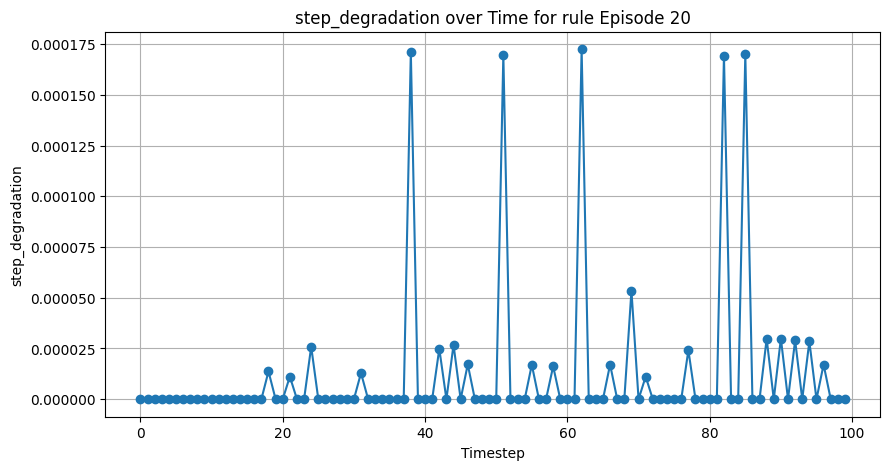

In [16]:
# examine any element from info and plot it
import matplotlib.pyplot as plt
info_list = []
debug_element = "step_degradation"
for info in df['info']:
    if info is None:
        info_list.append(None)
    elif isinstance(info, dict):
        info_list.append(info.get(debug_element))
    else:
        try:
            j = json.loads(info)
            if isinstance(j, dict):
                info_list.append(j.get(debug_element))
            else:
                info_list.append(None)
        except Exception:
            info_list.append(None)

info_list = info_list[:100]
# plot the extracted element over time
plt.figure(figsize=(10, 5))
plt.plot(info_list, marker='o', linestyle='-')
plt.xlabel('Timestep')
plt.ylabel(debug_element)
plt.title(f'{debug_element} over Time for {algo} Episode {ep}')
plt.grid(True)
plt.show()
 

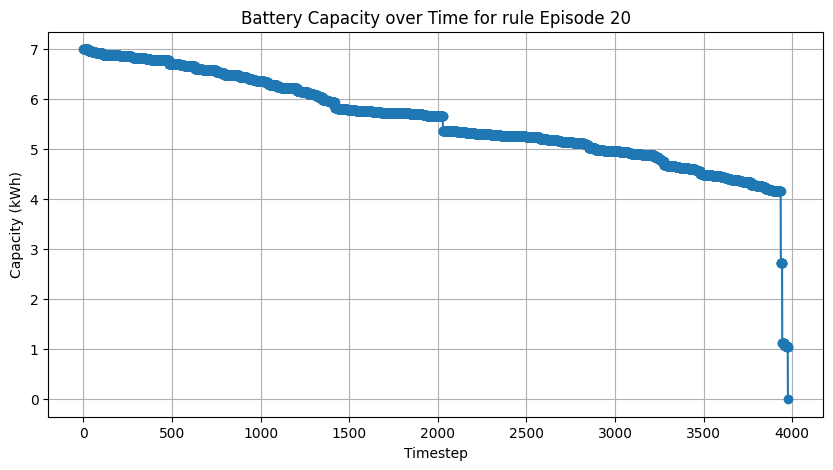

In [47]:
# plot capacity_kwh over time
plt.figure(figsize=(10, 5))
plt.plot(capacity_kwhs, marker='o', linestyle='-')
plt.xlabel('Timestep')
plt.ylabel('Capacity (kWh)')
plt.title(f'Battery Capacity over Time for {algo} Episode {ep}')
plt.grid(True)
plt.show()

In [38]:
# examine battery_level from info
battery_levels = []
num = 4000
for info in df.tail(num)['info']:
    if info is None:
        battery_levels.append(None)
    elif isinstance(info, dict):
        battery_levels.append(info.get('battery_level'))
    else:
        try:
            j = json.loads(info)
            if isinstance(j, dict):
                battery_levels.append(j.get('battery_level'))
            else:
                battery_levels.append(None)
        except Exception:
            try:
                j = ast.literal_eval(info)
                if isinstance(j, dict):
                    battery_levels.append(j.get('battery_level'))
                else:
                    battery_levels.append(None)
            except Exception:
                battery_levels.append(None) 

In [39]:
import numpy as np
from batterydeg import rainflow_counting

battery_capacity = 7.0  # or env.battery_capacity
soc = (np.array(battery_levels, dtype=float) / battery_capacity) * 100.0

cycles = rainflow_counting(soc, step_duration=0.5)
print("Turning-point cycles detected:", len(cycles))
if len(cycles) > 0:
    print("First 5 cycles:", cycles[:5])

Turning-point cycles detected: 275
First 5 cycles: [(np.float64(51.00244890366282), np.float64(90.31106723206385), np.float64(25.80316206630396), 0.0), (np.float64(51.12866321578622), np.float64(92.15864179922002), np.float64(15.359773633203337), 0.0), (np.float64(51.241085971040384), np.float64(92.43358543940953), 0.0, np.float64(23.10839635985238)), (np.float64(49.56998888935362), np.float64(80.9442034789494), 0.0, np.float64(23.12691527969983)), (np.float64(45.97181124346597), np.float64(91.94362248693194), 0.0, np.float64(22.985905621732986))]


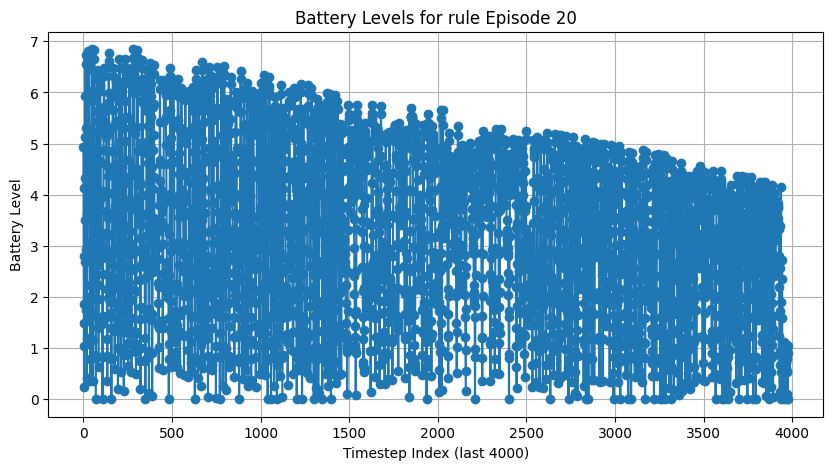

In [40]:
# plot battery levels
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(battery_levels, marker='o')
plt.title(f'Battery Levels for {algo} Episode {ep}')
plt.xlabel(f'Timestep Index (last {num})')
plt.ylabel('Battery Level')
plt.grid(True)
plt.show()

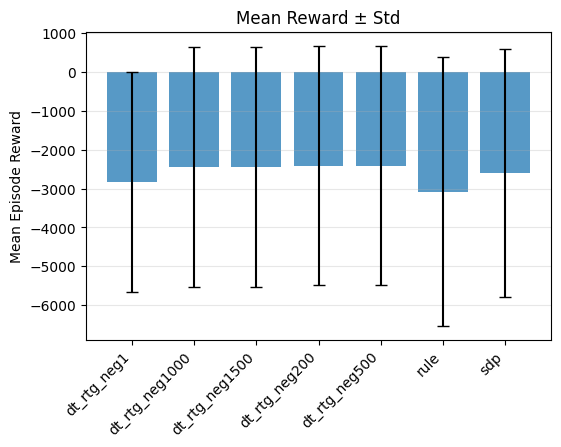

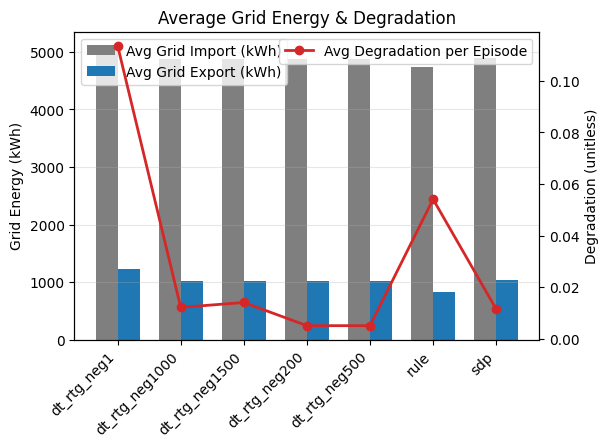

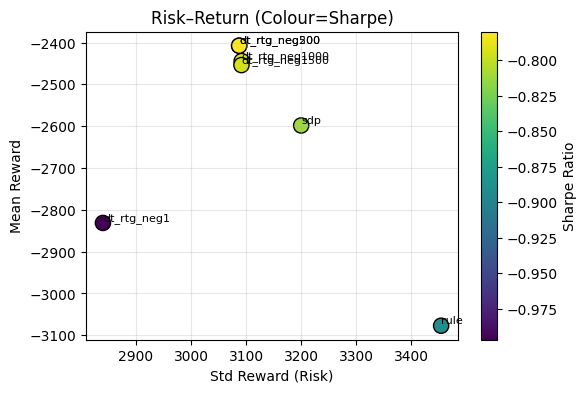

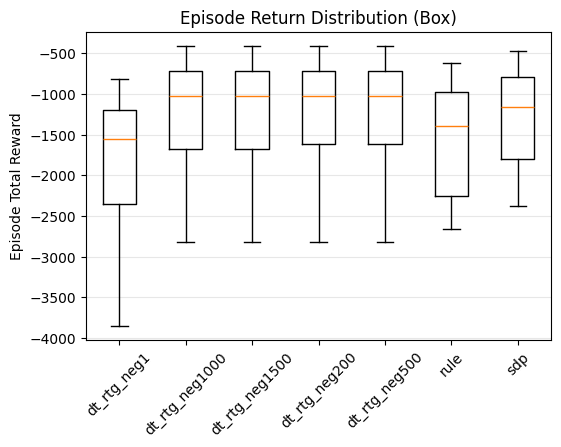

Saved evaluation metrics to: ../eval_output/dt_compare/evaluation_metrics.csv


In [37]:
from pathlib import Path
from helper import evaluate_experiments

base_save_dir = "eval_output/dt_compare"

# evaluate experiments outcomes
metrics = evaluate_experiments(combined_logs, target_return=0.0, save_dir=str(base_save_dir))

# log metrics as csv
metrics_csv_path = Path(base_save_dir) / "evaluation_metrics.csv"
metrics.write_csv(str(metrics_csv_path))
print(f"Saved evaluation metrics to: {metrics_csv_path}")



In [31]:
# check which labels associated with which index
for label, dfs in all_logs.items():
    print(f"Label: {label}, Number of episodes: {len(dfs)}")


Label: td3, Number of episodes: 60
Label: sac, Number of episodes: 60
Label: a2c, Number of episodes: 60
Label: sdp, Number of episodes: 60
Label: ddpg, Number of episodes: 60
Label: oracle, Number of episodes: 60
Label: dt_rtg_neg1, Number of episodes: 60
Label: mrdp, Number of episodes: 60
Label: ppo, Number of episodes: 60
Label: dt_rtg_neg1500, Number of episodes: 60
Label: dt_rtg_neg200, Number of episodes: 60
Label: rule, Number of episodes: 60
Label: dt_rtg_neg1000, Number of episodes: 60
Label: dt_rtg_neg500, Number of episodes: 60


In [33]:

random_ep = 42
label1 = "sdp"
df1 = all_logs[label1][random_ep]
label2 = "dt_rtg_neg1500"
df2 = all_logs[label2][random_ep]

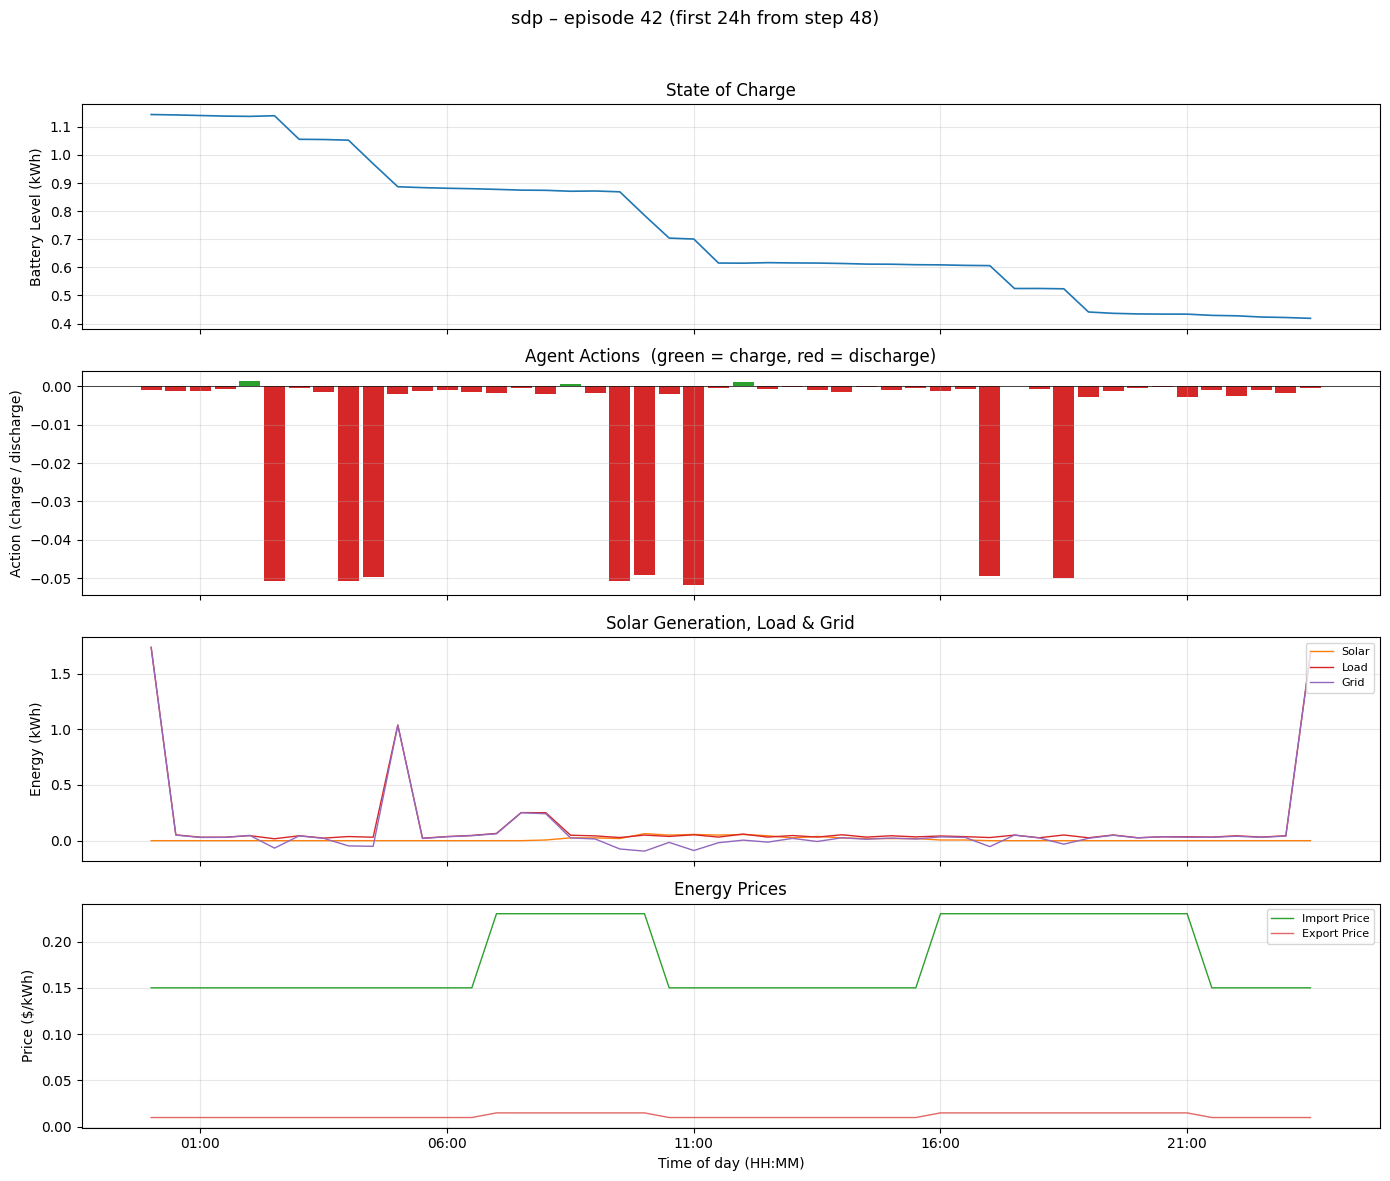

In [34]:
from helper import EpisodeVisualizer

vis = EpisodeVisualizer(df1, step_duration=0.5)
start_step = 48
num_hours = 24
title = f"{label1} – episode {random_ep} (first {num_hours}h from step {start_step})"
fig = vis.plot(start_step=start_step, num_hours=num_hours, title=title)

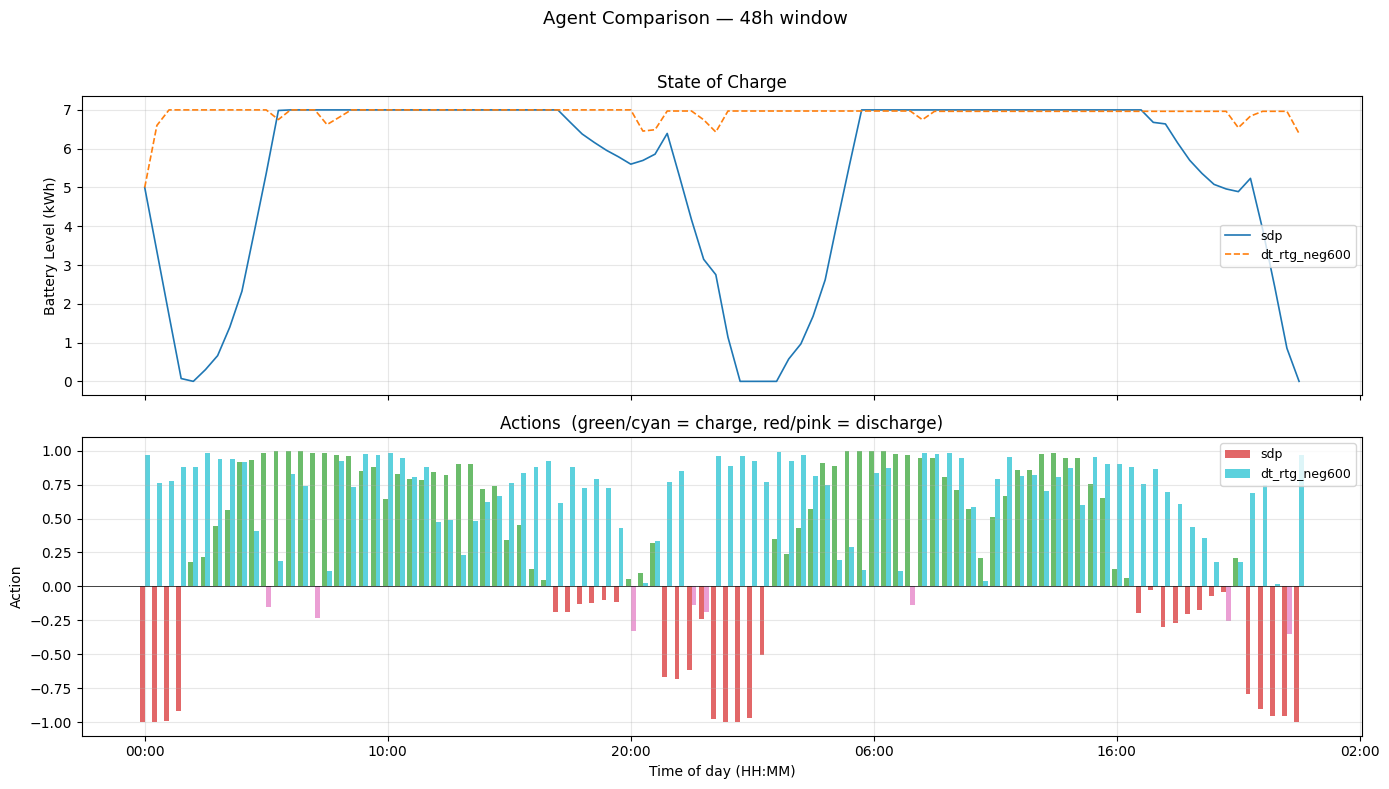

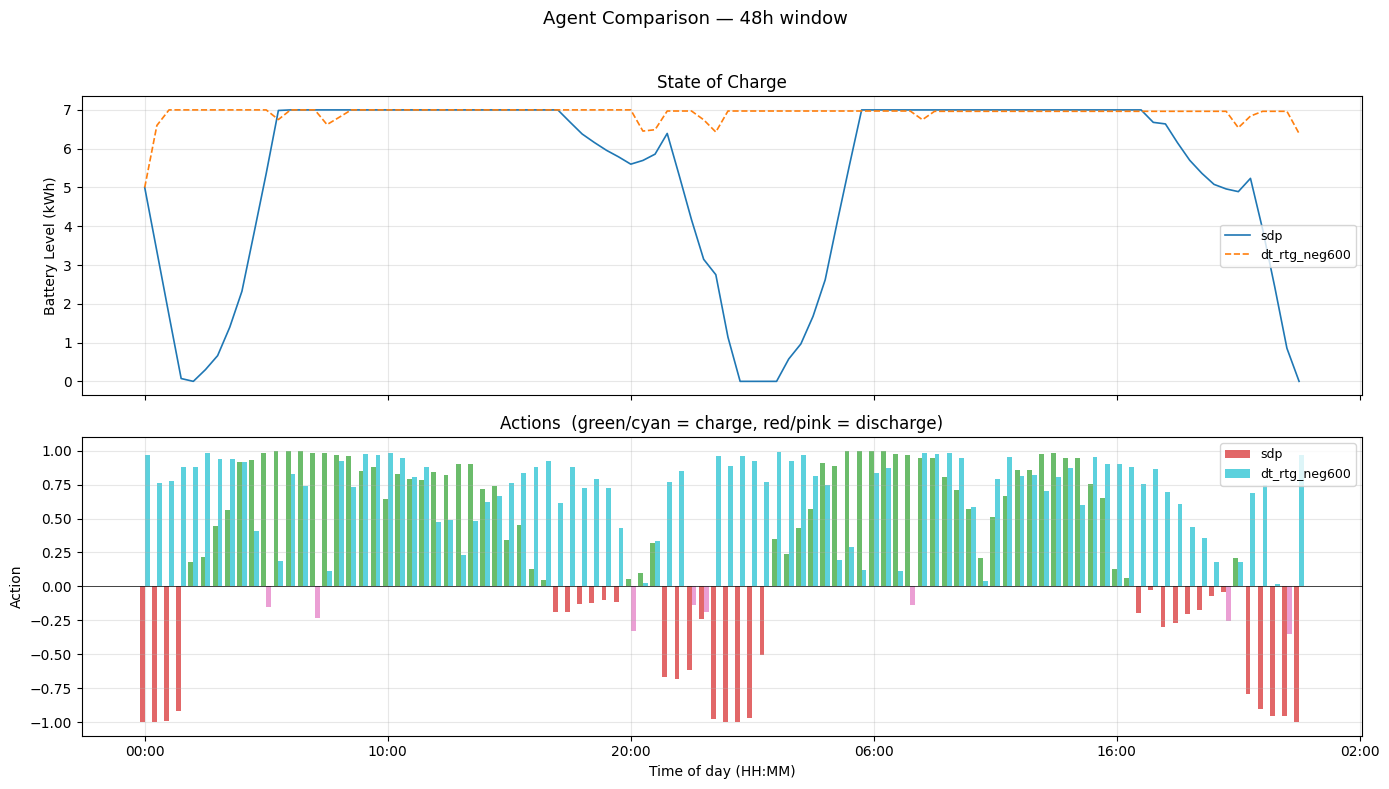

In [13]:
# need at least two algorithms with episodes
EpisodeVisualizer.compare(df1, df2, label1=label1, label2=label2, num_hours=48)

In [10]:
from pathlib import Path
import pandas as pd

eval_dir = Path("../eval_output")
svg_files = sorted(eval_dir.glob("*.svg"))
print(f"{len(svg_files)} SVGs in {eval_dir}:")
for svg in svg_files:
    print(" •", svg.name)

metrics = pd.read_csv(eval_dir / "evaluation_metrics.csv").set_index("experiment")
print("\nMean reward ranking (higher is better):")
print(metrics["mean_reward"].sort_values(ascending=False))

print("\nSharpe ratio ranking (less negative is better):")
print(metrics["sharpe_ratio"].sort_values(ascending=False))

print("\nWhere dt_rtg0 sits:")
print(metrics.loc["dt_rtg0", ["mean_reward", "sharpe_ratio"]])
print(f"Mean rank: {metrics['mean_reward'].rank(ascending=False).loc['dt_rtg0']}")
print(f"Sharpe rank: {metrics['sharpe_ratio'].rank(ascending=False).loc['dt_rtg0']}")

4 SVGs in ../eval_output:
 • episode_distribution.svg
 • grid_energy.svg
 • mean_reward.svg
 • risk_return.svg

Mean reward ranking (higher is better):
experiment
oracle    -2483.383510
a2c       -2528.621908
dt_rtg0   -2534.053004
sdp       -2598.349079
mrdp      -2766.602985
ppo       -2828.282043
rule      -3077.257924
td3       -3213.162911
sac       -3686.595343
ddpg      -4398.313643
Name: mean_reward, dtype: float64

Sharpe ratio ranking (less negative is better):
experiment
a2c       -0.781689
sdp       -0.811978
mrdp      -0.822483
ppo       -0.863363
dt_rtg0   -0.871202
rule      -0.890907
td3       -1.097340
oracle    -1.399903
sac       -1.699025
ddpg      -1.714796
Name: sharpe_ratio, dtype: float64

Where dt_rtg0 sits:
mean_reward    -2534.053004
sharpe_ratio      -0.871202
Name: dt_rtg0, dtype: float64
Mean rank: 3.0
Sharpe rank: 5.0


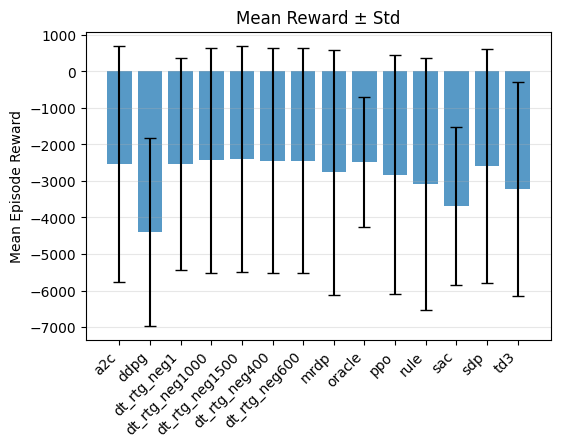

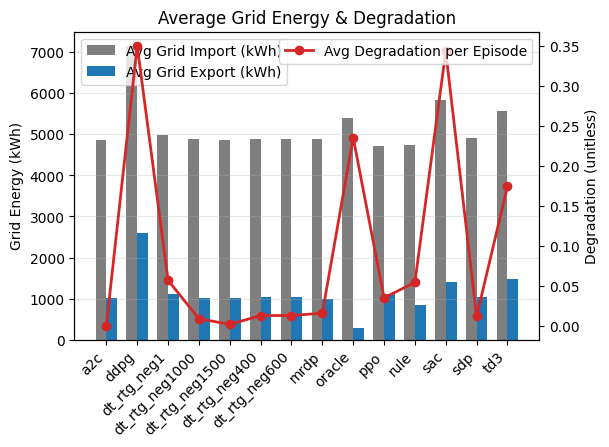

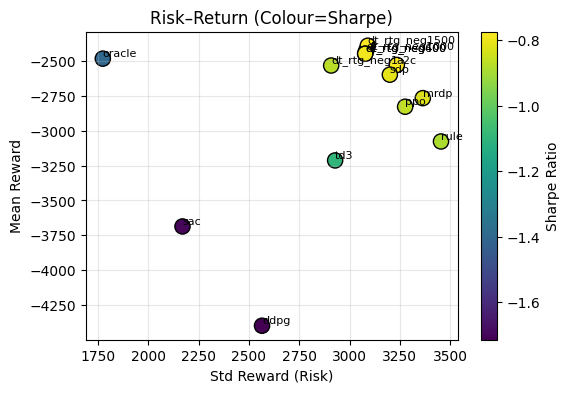

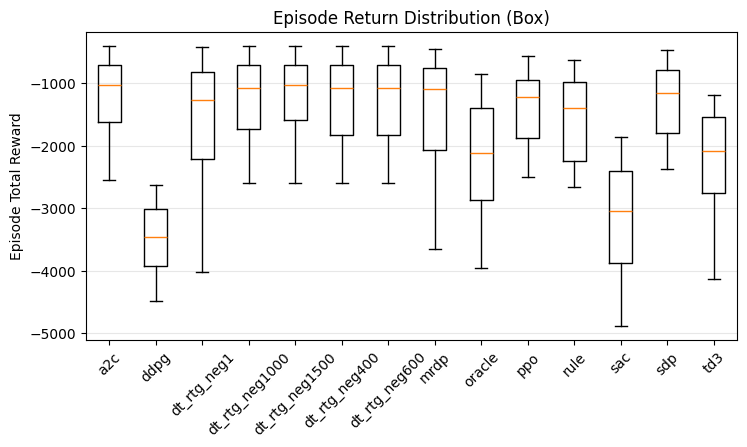

Best RTG to use: -404.5076717749115
RTG for SAC data: -625.6715603452078


In [ ]:
# just getting the recommended RTG values
from helper import evaluate_experiments
metrics = evaluate_experiments(all_logs, target_return=0.0, save_dir=None)

# 1. If you want the best RTG across ALL experiments/datasets provided:
best_overall_rtg = metrics["recommended_rtg"].max()
print(f"Best RTG to use: {best_overall_rtg}")

# 2. If you only want the RTG for a specific dataset (e.g. 'SAC_training_data'):
# Filter for that specific experiment name
specific_rtg = metrics.filter(pl.col("experiment") == "rule")["recommended_rtg"][0]
print(f"RTG for rule data: {specific_rtg}")

In [38]:
for algo, logs in all_logs.items():
    print(f"{algo}: {len(logs)} episodes")

td3: 60 episodes
sac: 60 episodes
a2c: 60 episodes
sdp: 60 episodes
ddpg: 60 episodes
oracle: 60 episodes
dt_rtg_neg1: 60 episodes
mrdp: 60 episodes
ppo: 60 episodes
dt_rtg_neg1500: 60 episodes
dt_rtg_neg200: 60 episodes
rule: 60 episodes
dt_rtg_neg1000: 60 episodes
dt_rtg_neg500: 60 episodes


In [39]:
from typing import Any
from helper import AlgorithmActionComparator, ActionComparisonConfig
def compare_action_pairwise_to_reference(
    logs_dict: dict[str, list[pl.DataFrame]],
    reference: str,
    base_save_dir: str | Path | None = None,
    **kwargs: Any,
 ) -> dict[str, Any]:
    """
    Run pairwise comparisons of each algorithm vs a reference algorithm.
    
    kwargs are forwarded to ActionComparisonConfig (e.g., bins, time_periods, etc.).
    Returns a dict: algo_name -> ActionComparisonResult or metrics dict.
    """
    comparator = AlgorithmActionComparator(action_logs=logs_dict)
    results: dict[str, Any] = {}
    for algo in logs_dict:
        if algo == reference:
            continue
        sub_logs = {reference: logs_dict[reference], algo: logs_dict[algo]}
        # If a base_save_dir is provided, create a per-pair subdirectory so output files don't overwrite each other
        if base_save_dir:
            out_dir = Path(base_save_dir) / f"{reference}_vs_{algo}"
            out_dir.mkdir(parents=True, exist_ok=True)
            kwargs_copy = dict(kwargs)
            # ensure we set save_dir to output dir
            kwargs_copy["save_dir"] = str(out_dir)
        else:
            kwargs_copy = kwargs
        cfg = ActionComparisonConfig(reference=reference, **kwargs_copy)
        result = comparator.compare(logs_dict=sub_logs, config=cfg)
        results[algo] = result
    return results


In [ ]:
steps_per_hour = int(1 / 0.5)  # number of steps per hour given a 30-min step duration (2)

def time_to_step(hour: int, minute: int = 0, second: int = 0, steps_per_hour_: int | None = None) -> int:
    """
    Convert a time-of-day (hour, minute, second) into a 0-indexed step mark for that day,
    using steps_per_hour (defaults to `steps_per_hour` defined above).
    Returns the floor of the step (i.e., which step interval that timestamp falls into).
    """
    sp = steps_per_hour_ or steps_per_hour
    total_seconds = hour * 3600 + minute * 60 + second
    seconds_per_step = 3600 / sp
    return int(total_seconds // seconds_per_step)

# time periods to compare in steps
# first 2 days, 2 days after 4th week, 2 days after 4th month, 2 days at 11th month (assuming 30-min per step, 48 steps/day)
first_step = 0
fourth_week = 4 * 7 * 48  # 4th week
fourth_month = 4 * 30 * 48  # 4th month
eleventh_month = 11 * 30 * 48  # 11th month
two_day_steps = 2 * 48

# morning period markers
five_am_mark = time_to_step(5, 0)   # 05:00
ten_am_mark = time_to_step(10, 0)   # 10:00

# mid-day marker
three_pm_mark = time_to_step(15, 0)  # 15:00

# evening marker
nine_pm_mark = time_to_step(21, 0)   # 21:00

# pick 52nd episode if exists for all algorithms
episode_52 = {}
for algo, logs in all_logs.items():
    if len(logs) > 52:
        episode_52[algo] = logs[52]

# Wrap single-episode DataFrames into lists expected by the comparator
episode_single = {k: [v] for k, v in episode_52.items()}

# check if we have data for episode 52
if not episode_52:
    print("No data available for episode 52 across the algorithms.")

KeyboardInterrupt: 

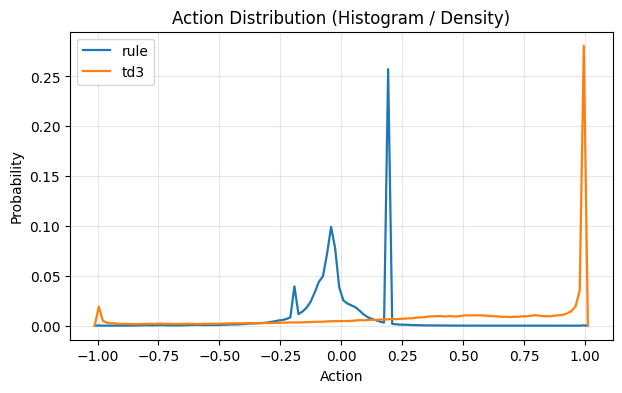

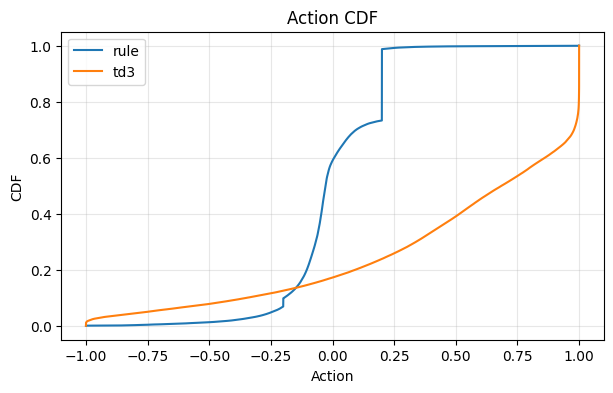

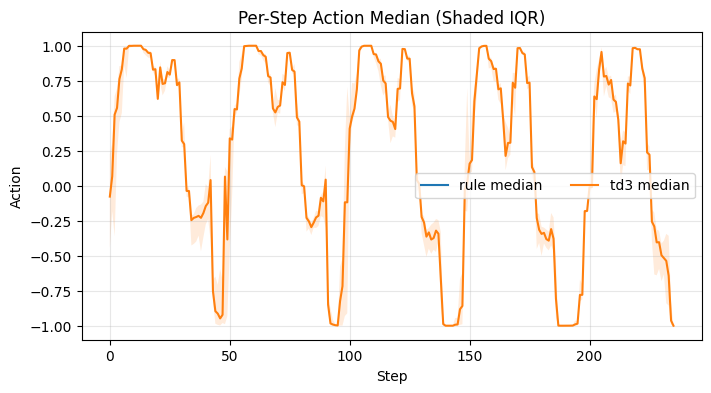

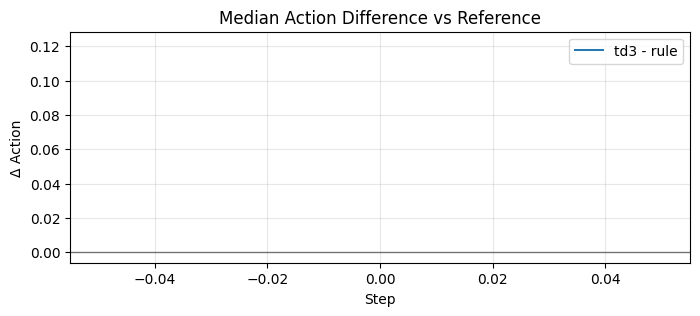

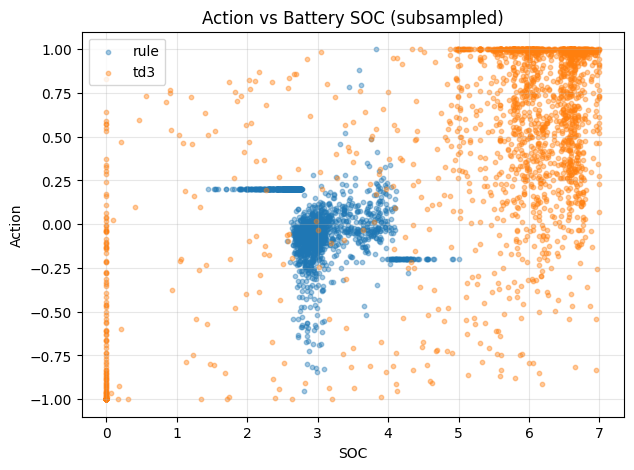

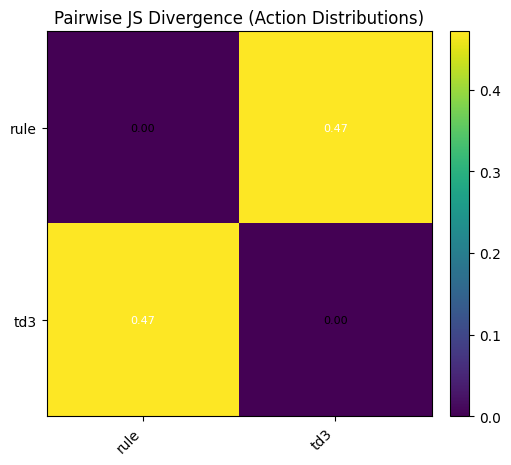

In [40]:
# overall comparison for action stat
base_save_dir = "../eval_output"
pairwise_results = compare_action_pairwise_to_reference(
    all_logs,
    reference="rule",
    base_save_dir=base_save_dir,
    time_periods=None,
    bins='auto',
    max_episodes=25 # only uses 25 episodes to compile the stat
 )

In [ ]:
"""
# Example: create named time windows (start_step, end_step) you can pass to the comparator
time_periods = {
    "first_2_days": (first_step, first_step + two_day_steps),
    "4th_week_2_days": (fourth_week, fourth_week + two_day_steps),
    "4th_month_2_days": (fourth_month, fourth_month + two_day_steps),
    "11th_month_2_days": (eleventh_month, eleventh_month + two_day_steps),
    "morning": (first_step + five_am_mark, first_step + ten_am_mark),
    "afternoon": (first_step + three_pm_mark, first_step + three_pm_mark + steps_per_hour),  # 1-hour window
    "evening": (first_step + nine_pm_mark, first_step + nine_pm_mark + steps_per_hour),     # 1-hour window
}
"""

time_periods = [
    (fourth_week, fourth_week + two_day_steps/2),
]

In [ ]:
from helper import AlgorithmActionComparator, TemporalAnalysisConfig
import matplotlib.pyplot as plt

# Use the same time_periods defined earlier and the episode_8964 mapping (algo -> DataFrame)
# episode_8964 maps algorithm -> single episode DataFrame; analyze_temporal expects dict[str, pl.DataFrame]
base_save_dir = "../eval_output"
comparator = AlgorithmActionComparator()
# Build a unique filename for the episode and involved algos

temporal_out_path = base_save_dir + "/temporal"
cfg = TemporalAnalysisConfig(time_periods=time_periods, annotate_states=True, step_duration=0.5, reference="rule", action_tolerance=0.01, save_path=str(temporal_out_path))

result = comparator.analyze_temporal(logs_dict=episode_52, config=cfg)
fig = result.figure
stats = result.stats

# Display stats and figure
print(stats)
# In notebooks, use display of Matplotlib figure
plt.show(fig)


In [ ]:
# Example: Evaluate rewards under different conditions for one algorithm
from helper import evaluate_by_conditions

# Define your conditions (functions that take obs and return True/False)
conditions = {
    "high_solar": lambda obs: obs[5] > 2.0,
    "peak_price": lambda obs: obs[7] > 0.2,
    "low_battery": lambda obs: obs[-2] < 0.3
}

# logs is a list of Polars DataFrames for one algorithm
results = evaluate_by_conditions(logs, conditions)
print(results)

## Risk-Sensitive Evaluation & Statistical Comparisons

The following cells demonstrate three new capabilities added to `helper.py`:
1. **CVaR / VaR** – tail-risk metrics returned by `evaluate_experiment_logs` and `evaluate_experiments`
2. **Bootstrap confidence intervals** – resampling-based CIs via `bootstrap_confidence_intervals`
3. **Paired statistical comparisons** – Wilcoxon signed-rank test via `paired_comparison`

In [41]:
# ── 1. CVaR / VaR risk metrics ──────────────────────────────────────────────
# evaluate_experiments now includes var_5 (Value-at-Risk at 5%) and
# cvar_5 (Conditional VaR / Expected Shortfall at 5%) for every experiment.
#
# var_5  = 5th-percentile of episode returns (worst-case threshold)
# cvar_5 = mean of returns at or below var_5  (expected tail loss)

from helper import evaluate_experiments

# Re-use the all_logs dict built earlier in this notebook.
# If you haven't run those cells yet, execute them first.
metrics = evaluate_experiments(all_logs, make_plots=False)

# Display the risk columns alongside mean reward
risk_cols = ["experiment", "mean_reward", "std_reward",
             "sharpe_ratio", "sortino_ratio", "var_5", "cvar_5"]
print(metrics.select(risk_cols))

shape: (14, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ experiment   ┆ mean_reward ┆ std_reward  ┆ sharpe_rati ┆ sortino_rat ┆ var_5       ┆ cvar_5      │
│ ---          ┆ ---         ┆ ---         ┆ o           ┆ io          ┆ ---         ┆ ---         │
│ str          ┆ f64         ┆ f64         ┆ ---         ┆ ---         ┆ f64         ┆ f64         │
│              ┆             ┆             ┆ f64         ┆ f64         ┆             ┆             │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ a2c          ┆ -2528.62190 ┆ 3234.816328 ┆ -0.781689   ┆ -0.781689   ┆ -9143.06475 ┆ -9966.43367 │
│              ┆ 8           ┆             ┆             ┆             ┆ 9           ┆ 8           │
│ ddpg         ┆ -4398.31364 ┆ 2564.918728 ┆ -1.714796   ┆ -1.714796   ┆ -10897.5228 ┆ -11734.4557 │
│              ┆ 3           ┆             ┆             ┆             ┆ 75 

In [42]:
# store the risk_cols as csv with remark explaining the what the head of each column means
from pathlib import Path

risk_df = metrics.select(risk_cols)
risk_csv = Path("../eval_output") / "risk_metrics.csv"

# human‑readable comments – they will appear at the top of the CSV
remarks = (
    "# experiment: name/label of the experiment\n"
    "# mean_reward: mean total reward across episodes\n"
    "# std_reward: standard deviation of episode rewards\n"
    "# sharpe_ratio: mean_reward / std_reward (risk‑adjusted return)\n"
    "# sortino_ratio: similar to Sharpe but only penalises downside\n"
    "# var_5: 5‑percentile of returns (Value‑at‑Risk at 5%)\n"
    "# cvar_5: mean of returns ≤ var_5 (Conditional VaR / expected tail loss)\n"
)

with open(risk_csv, "w") as f:
    f.write(remarks)
    risk_df.write_csv(f)

print(f"risk metrics written to {risk_csv}")


risk metrics written to ../eval_output/risk_metrics.csv


In [43]:
# ── 2. Bootstrap confidence intervals ────────────────────────────────────────
# Resample episode logs with replacement to build a distribution of the metric
# and derive confidence intervals.

from helper import bootstrap_confidence_intervals

# 95% CI on mean total reward, 1000 bootstrap samples, reproducible seed
cis = bootstrap_confidence_intervals(
    all_logs,
    n_bootstrap=1000,
    confidence_level=0.95,
    seed=42,
)

for algo, ci in sorted(cis.items()):
    print(f"{algo:>20s}:  mean={ci['mean']:+.2f}  "
          f"95% CI=[{ci['ci_lower']:+.2f}, {ci['ci_upper']:+.2f}]  "
          f"std={ci['std']:.2f}")

                 a2c:  mean=-2547.59  95% CI=[-3415.21, -1740.64]  std=429.60
                ddpg:  mean=-4412.98  95% CI=[-5080.49, -3816.91]  std=333.30
         dt_rtg_neg1:  mean=-2832.02  95% CI=[-3582.74, -2129.57]  std=374.89
      dt_rtg_neg1000:  mean=-2447.89  95% CI=[-3304.68, -1720.54]  std=406.59
      dt_rtg_neg1500:  mean=-2455.71  95% CI=[-3315.29, -1718.01]  std=404.79
       dt_rtg_neg200:  mean=-2409.26  95% CI=[-3199.42, -1673.25]  std=398.23
       dt_rtg_neg500:  mean=-2411.99  95% CI=[-3249.85, -1698.86]  std=391.22
                mrdp:  mean=-2757.86  95% CI=[-3634.84, -2001.99]  std=422.07
              oracle:  mean=-2471.82  95% CI=[-2965.54, -2065.39]  std=235.98
                 ppo:  mean=-2816.07  95% CI=[-3659.58, -2040.56]  std=427.46
                rule:  mean=-3094.44  95% CI=[-3995.51, -2260.61]  std=452.77
                 sac:  mean=-3679.71  95% CI=[-4266.23, -3173.92]  std=277.15
                 sdp:  mean=-2611.10  95% CI=[-3512.91, -1878.94

In [45]:
# ── 3. Paired statistical comparison (Wilcoxon signed-rank) ──────────────────
# Compare two algorithms on matched episodes (same seed/customer index).
# Requires both algorithms to have the same number of episodes.

from helper import paired_comparison

# Pick two algorithms present in all_logs to compare
algo_names = sorted(all_logs.keys())
if len(algo_names) >= 2:
    a = "dt_rtg_neg500"
    b = "sdp"
    result = paired_comparison(all_logs[a], all_logs[b])
    print(f"Paired comparison: {a} vs {b}")
    print(f"  mean_diff   = {result['mean_diff']:+.4f}")
    print(f"  median_diff = {result['median_diff']:+.4f}")
    print(f"  std_diff    = {result['std_diff']:.4f}")
    print(f"  Wilcoxon stat = {result['wilcoxon_stat']:.2f}")
    print(f"  Wilcoxon p    = {result['wilcoxon_p']:.4f}")
else:
    print("Need at least two algorithms in all_logs for paired comparison.")

Paired comparison: dt_rtg_neg500 vs sdp
  mean_diff   = +190.7275
  median_diff = +129.6281
  std_diff    = 4657.2020
  Wilcoxon stat = 790.00
  Wilcoxon p    = 0.3575


In [46]:
# ── 4. Pairwise comparison loop across all algorithm pairs ──────────────────
# Run paired_comparison for every pair and collect into a summary table.

import polars as pl
from itertools import combinations
from helper import paired_comparison

rows = []
for a, b in combinations(sorted(all_logs.keys()), 2):
    r = paired_comparison(all_logs[a], all_logs[b])
    rows.append({"algo_a": a, "algo_b": b, **r})

if rows:
    summary = pl.DataFrame(rows)
    print(summary)
else:
    print("Not enough algorithms for pairwise comparisons.")

shape: (91, 7)
┌────────┬────────────────┬──────────────┬──────────────┬─────────────┬───────────────┬────────────┐
│ algo_a ┆ algo_b         ┆ mean_diff    ┆ median_diff  ┆ std_diff    ┆ wilcoxon_stat ┆ wilcoxon_p │
│ ---    ┆ ---            ┆ ---          ┆ ---          ┆ ---         ┆ ---           ┆ ---        │
│ str    ┆ str            ┆ f64          ┆ f64          ┆ f64         ┆ f64           ┆ f64        │
╞════════╪════════════════╪══════════════╪══════════════╪═════════════╪═══════════════╪════════════╡
│ a2c    ┆ ddpg           ┆ 1869.691735  ┆ 2260.838375  ┆ 3188.216922 ┆ 324.0         ┆ 0.000014   │
│ a2c    ┆ dt_rtg_neg1    ┆ 302.824552   ┆ 495.214703   ┆ 4201.061528 ┆ 460.0         ┆ 0.000809   │
│ a2c    ┆ dt_rtg_neg1000 ┆ -84.357563   ┆ 5.189185     ┆ 4473.68769  ┆ 511.0         ┆ 0.002939   │
│ a2c    ┆ dt_rtg_neg1500 ┆ -74.664937   ┆ 5.031035     ┆ 4475.674639 ┆ 510.0         ┆ 0.002869   │
│ a2c    ┆ dt_rtg_neg200  ┆ -120.971843  ┆ 4.325548     ┆ 4462.620716 ┆ 471.

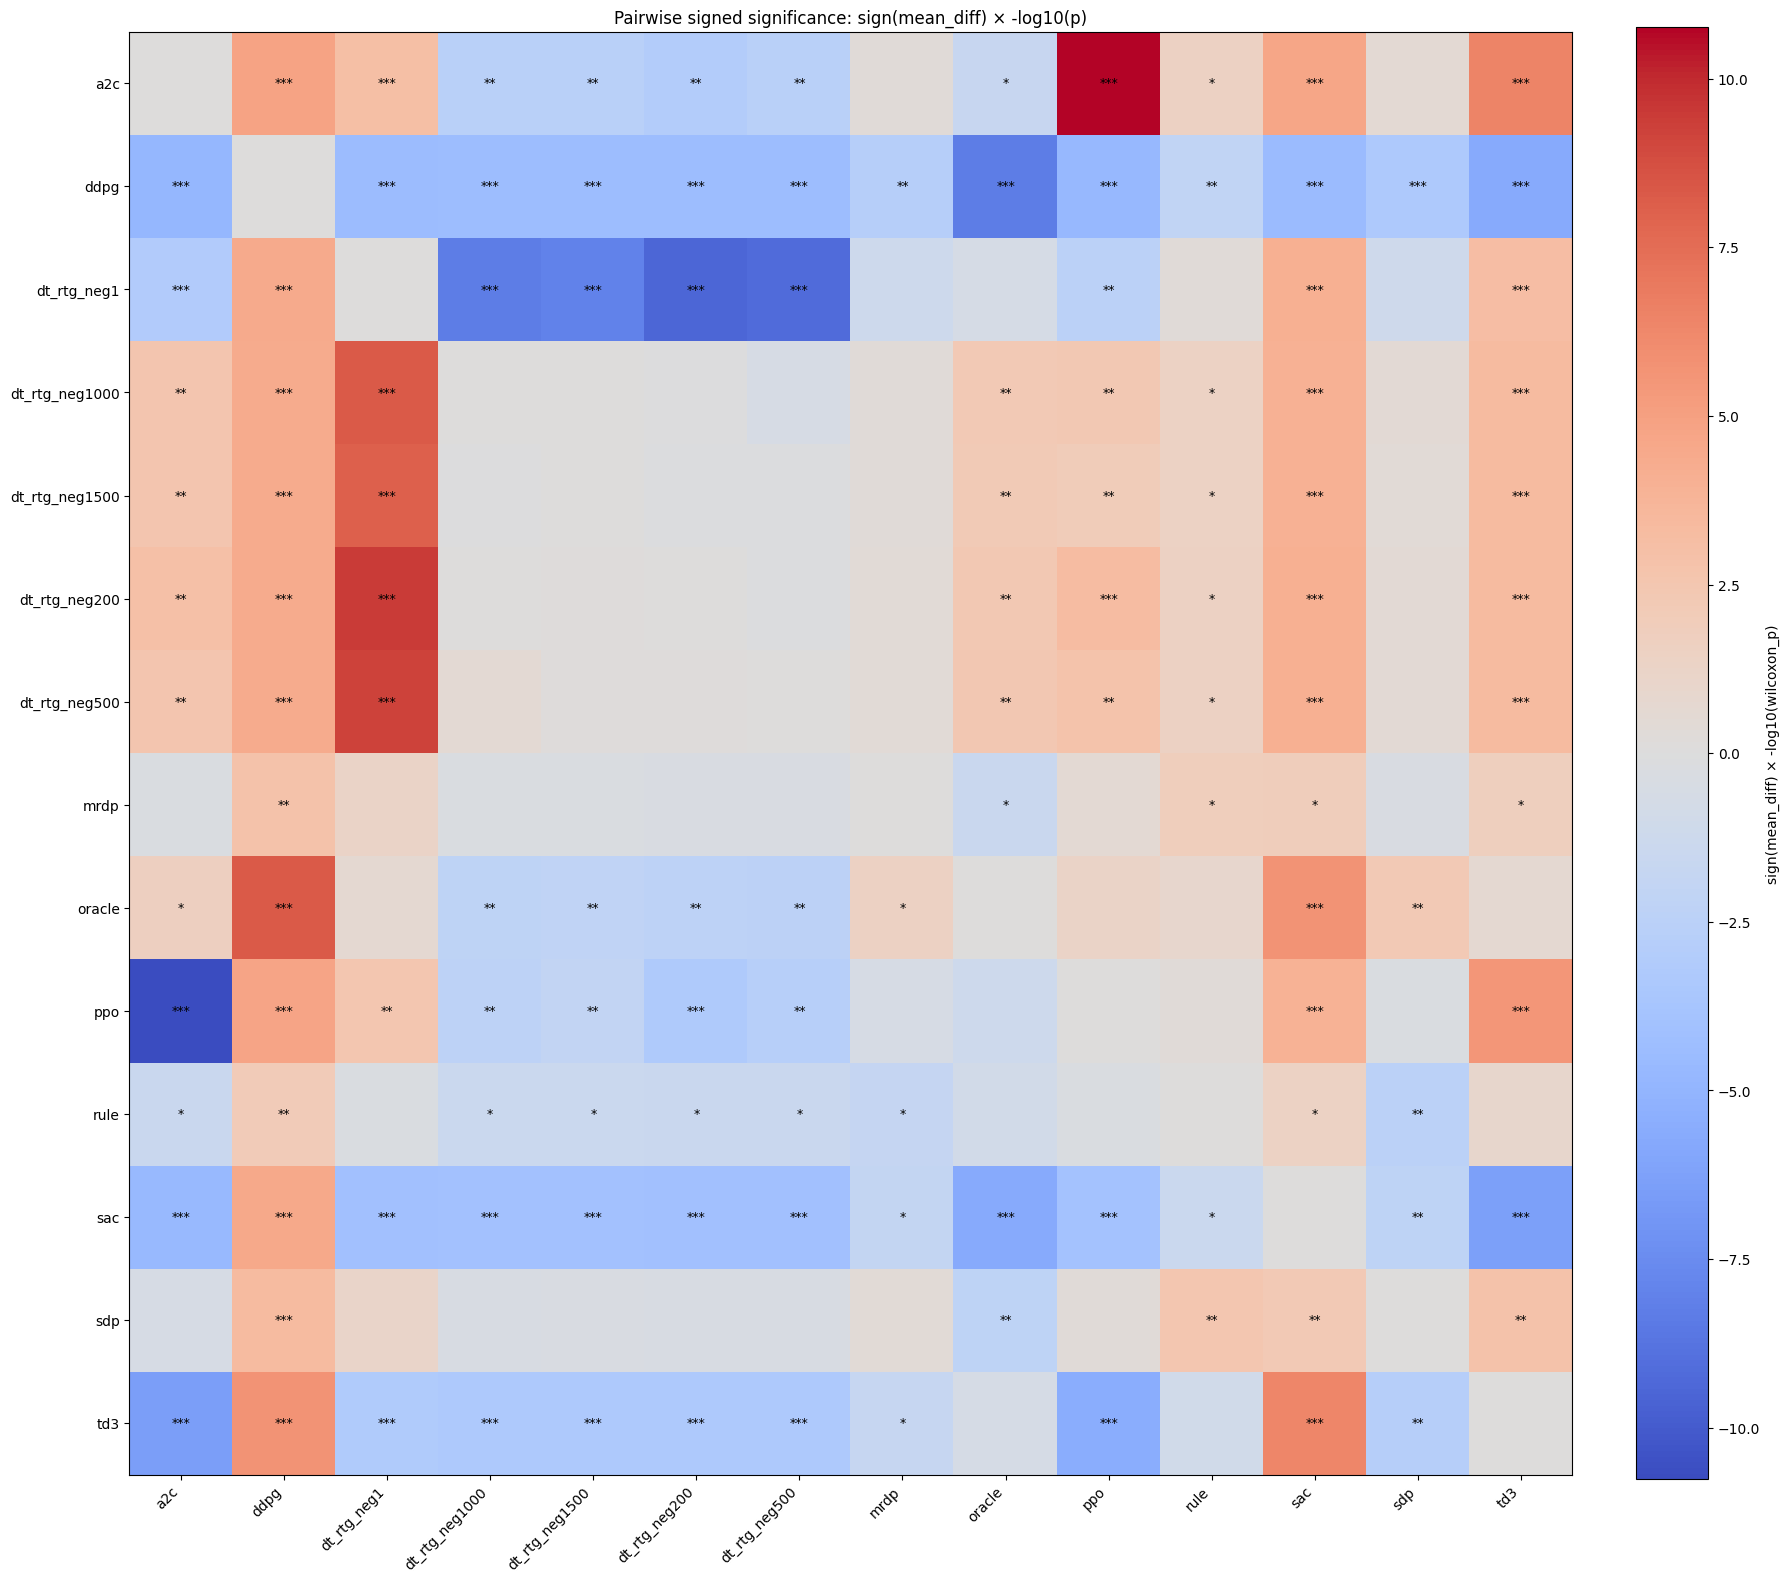

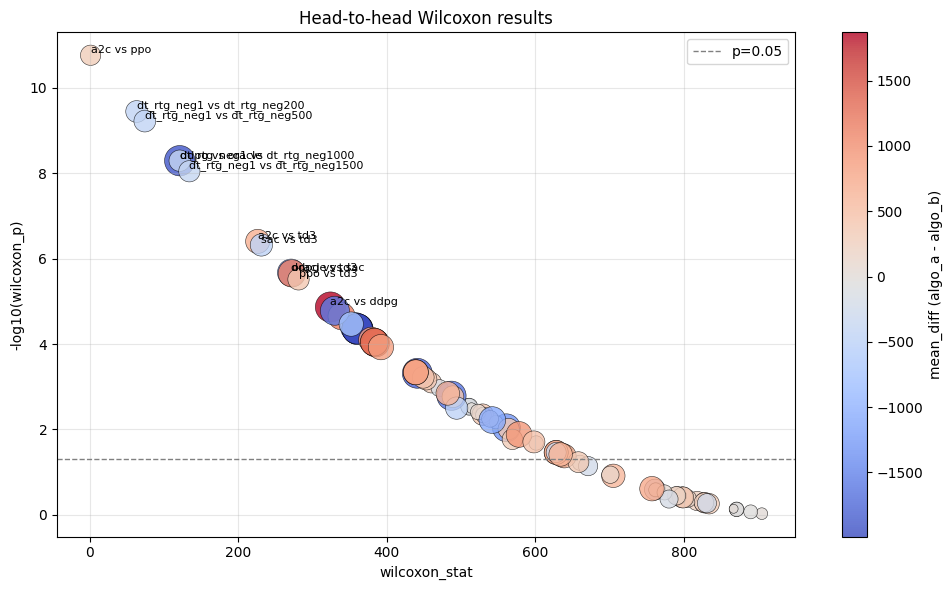

In [47]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

# Reuse in-memory `summary` if available; otherwise read from CSV (ignoring remark lines)
if "summary" in globals() and isinstance(summary, pl.DataFrame):
    sdf = summary.to_pandas()
else:
    sdf = pd.read_csv("eval_output/pairwise_summary.csv", comment="#")

required = {"algo_a", "algo_b", "mean_diff", "wilcoxon_stat", "wilcoxon_p"}
missing = required - set(sdf.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Clean p-values
eps = 1e-300
sdf["wilcoxon_p"] = pd.to_numeric(sdf["wilcoxon_p"], errors="coerce")
sdf["wilcoxon_stat"] = pd.to_numeric(sdf["wilcoxon_stat"], errors="coerce")
sdf["mean_diff"] = pd.to_numeric(sdf["mean_diff"], errors="coerce")
sdf = sdf.dropna(subset=["wilcoxon_p", "mean_diff"])
sdf["wilcoxon_p_clipped"] = sdf["wilcoxon_p"].clip(lower=eps, upper=1.0)

# Build algorithm index
algos = sorted(set(sdf["algo_a"]).union(set(sdf["algo_b"])))
idx = {a: i for i, a in enumerate(algos)}
n = len(algos)

# Matrices
score_mat = np.full((n, n), np.nan)   # sign(mean_diff) * -log10(p)
p_mat = np.full((n, n), np.nan)
stat_mat = np.full((n, n), np.nan)

for _, r in sdf.iterrows():
    a, b = r["algo_a"], r["algo_b"]
    i, j = idx[a], idx[b]

    sign = np.sign(r["mean_diff"]) if np.isfinite(r["mean_diff"]) else 0.0
    strength = -np.log10(r["wilcoxon_p_clipped"])
    score = sign * strength

    score_mat[i, j] = score
    score_mat[j, i] = -score  # opposite direction

    p_mat[i, j] = r["wilcoxon_p"]
    p_mat[j, i] = r["wilcoxon_p"]

    stat_mat[i, j] = r["wilcoxon_stat"]
    stat_mat[j, i] = r["wilcoxon_stat"]

np.fill_diagonal(score_mat, 0.0)

# -------- Plot 1: Signed significance heatmap --------
fig, ax = plt.subplots(figsize=(1.0 * n + 4, 1.0 * n + 3))
vmax = np.nanmax(np.abs(score_mat))
vmax = max(vmax, 1.0)

im = ax.imshow(score_mat, cmap="coolwarm", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(algos, rotation=45, ha="right")
ax.set_yticklabels(algos)
ax.set_title("Pairwise signed significance: sign(mean_diff) × -log10(p)")

# Mark significance levels
for i in range(n):
    for j in range(n):
        if i == j or not np.isfinite(p_mat[i, j]):
            continue
        p = p_mat[i, j]
        stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        if stars:
            ax.text(j, i, stars, ha="center", va="center", fontsize=9, color="black")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("sign(mean_diff) × -log10(wilcoxon_p)")

plt.tight_layout()
plt.show()

# -------- Plot 2: Global view (statistic vs p-value) --------
plot_df = sdf.copy()
plot_df["neglog10_p"] = -np.log10(plot_df["wilcoxon_p_clipped"])

fig2, ax2 = plt.subplots(figsize=(10, 6))
sc = ax2.scatter(
    plot_df["wilcoxon_stat"],
    plot_df["neglog10_p"],
    c=plot_df["mean_diff"],
    cmap="coolwarm",
    s=40 + 10 * np.sqrt(np.abs(plot_df["mean_diff"]).clip(lower=0)),
    alpha=0.8,
    edgecolors="k",
    linewidths=0.4,
)
ax2.axhline(-np.log10(0.05), color="gray", linestyle="--", linewidth=1, label="p=0.05")
ax2.set_xlabel("wilcoxon_stat")
ax2.set_ylabel("-log10(wilcoxon_p)")
ax2.set_title("Head-to-head Wilcoxon results")
ax2.grid(alpha=0.3)
ax2.legend(loc="upper right")

cbar2 = fig2.colorbar(sc, ax=ax2)
cbar2.set_label("mean_diff (algo_a - algo_b)")

# Optional: label only strongest few points to avoid clutter
top = plot_df.sort_values("neglog10_p", ascending=False).head(12)
for _, r in top.iterrows():
    ax2.text(
        r["wilcoxon_stat"], r["neglog10_p"],
        f"{r['algo_a']} vs {r['algo_b']}",
        fontsize=8, ha="left", va="bottom"
    )

plt.tight_layout()
plt.show()

In [48]:
from pathlib import Path
base_save_dir = "../eval_output"
# save the figures under the eval_output directory with descriptive names
fig.savefig(Path(base_save_dir) / "pairwise_significance_heatmap.svg")
fig2.savefig(Path(base_save_dir) / "wilcoxon_stat_vs_pvalue.svg")

In [49]:
from pathlib import Path
# write the summary out with human‑readable header comments
summary_csv = Path("../eval_output") / "pairwise_summary.csv"
remarks = (
    "# algo_a: first algorithm in the pair\n"
    "# algo_b: second algorithm in the pair\n"
    "# mean_diff: mean reward difference (algo_a – algo_b)\n"
    "# median_diff: median of reward differences\n"
    "# std_diff: standard deviation of the differences\n"
    "# wilcoxon_stat: Wilcoxon signed‑rank statistic\n"
    "# wilcoxon_p: p‑value from the Wilcoxon test\n"
)
with open(summary_csv, "w") as f:
    f.write(remarks)
    summary.write_csv(f)
print(f"pairwise summary written to {summary_csv}")

pairwise summary written to ../eval_output/pairwise_summary.csv
